<a href="https://colab.research.google.com/github/taavip/DL4CV/blob/main/HW3_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework #3**
## Vision Transformers

This colaboratory contains Homework #3 of the Deep Learning for Computer Vision course, which is due **April 19, Sunday 2026, midnight (23:59 EET time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.

**NB! Links to your colaboratory will not be accepted as a solution!**

## Submission's rules:

1. Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:
1. Pooh

## List of Homework's exercises:
1. [EX1](#scrollTo=Qva9-9bIc8OL&uniqifier=1) - 5 points
2. [EX2](#scrollTo=6KSejfW0c8Og&uniqifier=1) - 8 points (+ up to 3 bonus points)
3. [EX3](#scrollTo=rJv0SN_ic8Oo&uniqifier=1) - 5 points


<a id='exercise_1'></a>
# **Exercise 1 (5 points): Back to Vision Transformer and Multi-Head Attention**

<font color='red'> In the first exercise of your homework, you will take a detailed look at a ground-up implementation of the famous Vision Transformer (ViT) model. We examined one during the practice session for a classification task. Here, you will practice implementing ViT from the beginning. Additionally, we previously used a Torch implementation of Multi-Head Attention (e.g., `nn.MultiheadAttention`). In this homework, we will implement one ourselves and compare its performance.  

In [20]:
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.notebook import tqdm_notebook

from tqdm import tqdm

In [21]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.datasets import VOCSegmentation
from torch.utils.data import DataLoader, Dataset
import timm

In [22]:
random.seed(3407)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


<font color='red'> Let's first start by loading the MNIST dataset, as we did previously. We will be using it to train our Transformer classifier.  

In [23]:
transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
                                             torchvision.transforms.Normalize((0.5,), (0.5,))])

# download MNIST training set and reserve 50000 for training
train_dataset = torchvision.datasets.MNIST(root='./data/MNIST', train=True,
                                           download=True, transform=transforms)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# download MNIST test set
test_set = torchvision.datasets.MNIST(root='./data/MNIST', train=False,
                                      download=True, transform=transforms)


# We define the data loaders using the datasets
train_loader = torch.utils.data.DataLoader(dataset=train_set, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_set, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_set, batch_size=32, shuffle=False)

<font color='red'>**(Homework exercise 1 – a)** In the first exercise we will be implementing the Vision Tranformer model we have look into on our practice session. You can refer to it using this link.
Implement the division on an image into patches.
(0.5 points)</font>

<font color='red'> Remember that in ViT, we start by dividing our image into 16x16 patches. We can implement this using the `torch.reshape()` function. First, we divide our spatial dimensions by the patch size, and then we merge everything into the channel dimension. The resulting tensor should have the shape `(b, l, d)`, where `l` is the number of patches in our image and `d` is the dimension of each patch. This dimension effectively consists of all flattened pixels in a given patch and the original channel dimension of our image.  

<font color='red'> Define a patch size and implement the patchification process below.  

In [24]:
#### YOUR CODE STARTS HERE ####

x = torch.randn(1, 3, 64, 64)
patch_size = 16

B, C, H, W = x.shape
# Divide spatial dimensions by patch_size, then flatten patches
x = x.reshape(B, C, H // patch_size, patch_size, W // patch_size, patch_size)
x = x.permute(0, 2, 4, 3, 5, 1).flatten(1, 2).flatten(2)
#### YOUR CODE ENDS HERE ####

print(x.shape)

# expect to get a tensor of shape (1, 16, 768)
assert x.shape == torch.Size([1, 16, 768])

torch.Size([1, 16, 768])


<font color='red'>**(Homework exercise 1 – b)** Implement InputEmbedding, EncoderBlock, and VitTransformer (2.5 points)</font>

<font color='red'> Now, we can implement a wrapper function called `ImageEmbedding`, which will divide our input image into patches, apply an `nn.Linear` projection on them, and return patch embeddings (tokens). Since we are implementing a Vision Transformer for classification, we also need a `[cls]` token, which we concatenate to our sequence. In `ImageEmbedding`, we additionally add learnable positional embeddings for each token in our sequence.  

<font color='red'> Below, implement the required functionality for the `ImageEmbedding` class. The `get_patches()` implementation should be the same as the one you defined above.  


In [25]:
class InputEmbedding(nn.Module):
	def __init__(self, patch_size, n_channels, embed_dim, num_patches):
		super(InputEmbedding, self).__init__()

        #### YOUR CODE STARTS HERE ####
		self.patch_size = patch_size
		self.n_channels = n_channels
		self.embed_dim = embed_dim

		self.proj = nn.Linear(patch_size * patch_size * n_channels, embed_dim)
		self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))
		self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        #### YOUR CODE ENDS HERE ####

	def get_patches(self, x):
        #### YOUR CODE STARTS HERE ####
		B, C, H, W = x.shape
        # your patching goes here
		x = x.reshape(B, C, H // self.patch_size, self.patch_size, W // self.patch_size, self.patch_size)
		x = x.permute(0, 2, 4, 3, 5, 1).flatten(1, 2).flatten(2)
        #### YOUR CODE ENDS HERE ####

		return x

	def forward(self, x):
		batch_size = x.shape[0]

        #### YOUR CODE STARTS HERE ####
		# (b, c, h, w) -> (b, num_patches, embed_dim)
		patches = self.get_patches(x)
		x = self.proj(patches)

		class_token = self.class_token.expand(batch_size, -1, -1)
		x = torch.cat((class_token, x), dim=1)
		x = x + self.pos_embed
        #### YOUR CODE ENDS HERE ####

		return x

<font color='red'> The `EncoderBlock` will encapsulate the attention part as well as the feed-forward (MLP) part. Implement the `EncoderBlock` functionality. For `self.attn`, use the `torch.nn` implementation.  

In [26]:
class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of input and attention feature vectors
            num_heads - Number of heads to use in the Multi-Head Attention block
            dropout - Amount of dropout to apply in the feed-forward network
        """
        super().__init__()

        #### YOUR CODE STARTS HERE ####
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.proj = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout)
        )
        #### YOUR CODE ENDS HERE ####

    def forward(self, x):
        #### YOUR CODE STARTS HERE ####
        # Attention sub-layer with residual connection
        x_norm = self.norm1(x)
        attn_output, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_output

        # Feed-forward sub-layer with residual connection
        x = x + self.proj(self.norm2(x))
        #### YOUR CODE ENDS HERE ####

        return x

<font color='red'> Now, let's put everything together! Given an image, we will first use `self.embedding` to get our tokens. After that, we should apply our `self.encoder` blocks to refine the tokens and share information with our (initially) random `[cls]` token. Finally, to get class probabilities, we need to apply an MLP head to our `[cls]` token.  

<font color='red'> Thus, after the encoder blocks, retrieve the `[cls]` token and feed it to the MLP layer.  

<font color='red'> **Q:** Do we need to add a `softmax()` activation at the end (yes/no?) and why?  

In [27]:
class VitTransformer(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        img_size,
        dropout=0.0,
    ):
        """
        Inputs:
            embed_dim - Dimensionality of the input feature vectors to the Transformer
            num_channels - Number of channels of the input (3 for RGB or 1 for grayscale)
            num_layers - Number of layers to use in the Transformer
            num_classes - Number of classes to predict
            patch_size - Number of pixels that the patches have per dimension
            img_size - Image size
            dropout - Amount of dropout to apply in the feed-forward network and
                      on the input encoding
        """
        super().__init__()

        num_patches = (img_size // patch_size) ** 2

        #### YOUR CODE STARTS HERE ####
        self.embedding = InputEmbedding(patch_size, num_channels, embed_dim, num_patches)

        self.encoders = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
        self.dropout = nn.Dropout(dropout)
        #### YOUR CODE ENDS HERE ####


    def forward(self, x):
        #### YOUR CODE STARTS HERE ####
        x = self.embedding(x)
        x = self.dropout(x)

        for encoder in self.encoders:
            x = encoder(x)

        # Retrieve the [cls] token (first element in the sequence)
        cls = x[:, 0]
        out = self.mlp_head(cls)
        #### YOUR CODE ENDS HERE ####

        return out

<font color='red'> **Your answer goes here:**

No, we do not need to add a softmax() activation at the end. Because in PyTorch, the standard classification loss function nn.CrossEntropyLoss expects raw logits as input. It internally computes the softmax and the negative log-likelihood loss together in a numerically stable way. Adding an explicit softmax would be redundant and could potentially lead to less stable gradients.

<font color='red'> Let's now test our implementation of ViT. Define meaningful parameters for ViT, which we will train on the MNIST dataset.  

<font color='red'> Explain the main parameters and your choice behind them.  

In [28]:
#### YOUR CODE STARTS HERE ####
image_size = 28
patch_size = 4
num_channels = 1
embed_dim = 64
num_heads = 4
num_layers = 3
num_classes = 10
dropout = 0.1
batch_size = 64
epochs = 10
base_lr = 1e-3
weight_decay = 1e-4
#### YOUR CODE ENDS HERE ####

<font color='red'> **Your answer goes here:**

1.  **`image_size = 28`**: This is the standard resolution for MNIST images.
2.  **`patch_size = 4`**: Since the image is only 28x28, a larger patch size (like 16) would result in too few tokens (only 1 or 4). A 4x4 patch provides 49 tokens, which is sufficient for the Transformer to learn spatial relationships.
3.  **`num_channels = 1`**: MNIST is a grayscale dataset, so there is only one input channel.
4.  **`embed_dim = 64`**: A relatively small embedding dimension is chosen to prevent overfitting, as MNIST is a simple dataset, while still providing enough capacity for the model to represent features.
5.  **`num_heads = 4`**: Using multiple heads allows the model to attend to different parts of the image patches simultaneously. 4 heads is balanced for an `embed_dim` of 64 (16 dimensions per head).
6.  **`num_layers = 3`**: A shallow stack of 3 encoder blocks is enough to reach high accuracy on digits without excessive computational cost.
7.  **`dropout = 0.1`**: A small amount of dropout is added to improve generalization and prevent the model from memorizing the training set.

In [29]:
model = VitTransformer(
    img_size=image_size,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    patch_size=patch_size,
    num_channels=num_channels,
    num_classes=num_classes,
    dropout=dropout
).to(device)

In [30]:
x = torch.randn(batch_size, num_channels, image_size, image_size).to(device)
out = model(x)
print(x.shape)
print(out.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])


In [31]:
# here is a sanity check for an output shape
assert out.shape == torch.Size([batch_size, num_classes])

<font color='red'>**(Homework exercise 1 – c)** For the second part implemnt the Trainer which will take the job of training and evaluating your ViT classification model. (2 points)</font>

<font color='red'> Now, we will implement another important component to train our Vision Transformer model. Sometimes, it is useful not only to have a training loop but also to encapsulate everything in a single instance to better track experiments when running the model multiple times with different configurations.  

<font color='red'> Here, we implement a simple general `Trainer()` instance. This trainer will receive the required parameters as input and will handle training inside the `Trainer.train()` function. The `train` function will run a loop over the epochs, with a training step and a validation step over the entire set of batches.  

<font color='red'> Additionally, the `Trainer` will implement a `.test()` function to evaluate the performance of our model (`self.model`).  

<font color='red'> Implement the functionality for `train_step()`, `valid_step()`, and `test()`.  

In [32]:
class Trainer:
    def __init__(self,
                 max_epochs,
                 model,
                 criterion,
                 optimizer,
                 scheduler,
                 device,
                 train_loader,
                 valid_loader,
                 test_loader,
				 log_every_n_steps=50
    ) -> None:
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader
        self.max_epochs = max_epochs
        self.log_every_n_steps = log_every_n_steps


    def train_step(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(self.train_loader, desc="Training")

        for batch_idx, (inputs, targets) in enumerate(pbar):
            inputs, targets = inputs.to(self.device), targets.to(self.device)

            #### YOUR CODE STARTS HERE ####
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()
            #### YOUR CODE ENDS HERE ####

            running_loss += loss.item()

            #### YOUR CODE STARTS HERE ####
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)

            if batch_idx % self.log_every_n_steps == 0:
                avg_loss = running_loss / (batch_idx + 1)
                accuracy = 100 * correct / total
                pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{accuracy:.2f}%")
            #### YOUR CODE ENDS HERE ####

        avg_loss = running_loss / len(self.train_loader)
        accuracy = 100 * correct / total
        pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{accuracy:.2f}%")
        return avg_loss, accuracy


    def valid_step(self):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            pbar = tqdm(self.valid_loader, desc="Validation")

            for batch_idx, (inputs, targets) in enumerate(pbar):
                inputs, targets = inputs.to(self.device), targets.to(self.device)

                #### YOUR CODE STARTS HERE ####
                outputs = self.model(inputs)
                loss = self.criterion(outputs, targets)
                #### YOUR CODE ENDS HERE ####

                running_loss += loss.item()

                #### YOUR CODE STARTS HERE ####
                _, predicted = outputs.max(1)
                correct += predicted.eq(targets).sum().item()
                total += targets.size(0)

                if batch_idx % self.log_every_n_steps == 0:
                    avg_loss = running_loss / (batch_idx + 1)
                    accuracy = 100 * correct / total
                    pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{accuracy:.2f}%")
                #### YOUR CODE ENDS HERE ####

            avg_loss = running_loss / len(self.valid_loader)
            accuracy = 100 * correct / total
            pbar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{accuracy:.2f}%")

        return avg_loss, accuracy

    def train(self):
        self.model.to(self.device)
        train_losses = []
        train_accuracies = []
        valid_losses = []
        valid_accuracies = []

        for epoch in range(self.max_epochs):
            train_loss, train_acc = self.train_step()
            valid_loss, valid_acc = self.valid_step()

            self.scheduler.step()

            train_losses.append(train_loss)
            train_accuracies.append(train_acc)
            valid_losses.append(valid_loss)
            valid_accuracies.append(valid_acc)

            print(f"Epoch {epoch+1}/{self.max_epochs}: train_loss: {train_loss:.4f}, train_acc: {train_acc:.2f}%, valid_loss: {valid_loss:.4f}, valid_acc: {valid_acc:.2f}%")
            print()

        return train_losses, train_accuracies, valid_losses, valid_accuracies

    def test(self):
        self.model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            pbar = tqdm(self.test_loader, desc="Testing")

            for inputs, targets in pbar:
                #### YOUR CODE STARTS HERE ####
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                _, predicted = outputs.max(1)
                correct += predicted.eq(targets).sum().item()
                total += targets.size(0)
                #### YOUR CODE ENDS HERE ####

            accuracy = 100 * correct / total
            print(f"test_acc: {accuracy:.2f}%")

        return accuracy

    def plot_metrics(self, train_losses, train_accuracies, valid_losses, valid_accuracies):
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        ax[0].plot(train_losses, label="train_loss", color="blue")
        ax[0].plot(valid_losses, label="valid_loss", linestyle="--", color="orange")
        ax[0].set_title("Losses")

        ax[1].plot(train_accuracies, label="train_acc", color="blue")
        ax[1].plot(valid_accuracies, label="valid_acc", linestyle="--", color="orange")
        ax[1].set_title("Accuracies")

        for i in range(2):
            ax[i].legend()
            ax[i].grid(0.35)
            ax[i].set_xlabel("Epochs")

        plt.show()

<font color='red'> Now, for the task of classifying MNIST images into numbers, define our optimizer, loss function, and scheduler.  

<font color='red'> *(Tip: Make sure the scheduler step is placed correctly in the Trainer; different schedulers work with different steps.)*  

<font color='red'> Also, define your `Trainer` with a sufficiently large number of epochs.  

In [33]:
#### YOUR CODE STARTS HERE ####
optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

trainer = Trainer(
    max_epochs=epochs,
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    train_loader=train_loader,
    valid_loader=val_loader,
    test_loader=test_loader
)
#### YOUR CODE ENDS HERE ####

<font color='red'> Now lets run our training!!! Your should expect to get valid_acc ~96%

In [34]:
train_losses, train_accuracies, valid_losses, valid_accuracies = trainer.train()

Validation: 100%|██████████| 313/313 [00:11<00:00, 28.21it/s, acc=94.11%, loss=0.1951]


Epoch 1/10: train_loss: 0.4870, train_acc: 84.07%, valid_loss: 0.1951, valid_acc: 94.13%



Validation: 100%|██████████| 313/313 [00:10<00:00, 28.89it/s, acc=96.23%, loss=0.1300]


Epoch 2/10: train_loss: 0.1983, train_acc: 93.74%, valid_loss: 0.1305, valid_acc: 96.21%



Validation: 100%|██████████| 313/313 [00:11<00:00, 28.22it/s, acc=96.83%, loss=0.1013]


...

Epoch 8/10: train_loss: 0.0520, train_acc: 98.33%, valid_loss: 0.0563, valid_acc: 98.32%



Validation: 100%|██████████| 313/313 [00:11<00:00, 28.11it/s, acc=98.63%, loss=0.0535]


Epoch 9/10: train_loss: 0.0443, train_acc: 98.57%, valid_loss: 0.0538, valid_acc: 98.61%



Validation: 100%|██████████| 313/313 [00:10<00:00, 29.47it/s, acc=98.62%, loss=0.0506]

Epoch 10/10: train_loss: 0.0388, train_acc: 98.78%, valid_loss: 0.0509, valid_acc: 98.60%



In [35]:
train_losses

[0.48700460501882753,
 0.198314822513684,
 0.1469609314139029,
 0.11646634237739477,
 0.0943471348727681,
 0.07701353386407378,
 0.06364262806369625,
 0.05201531389321666,
 0.04431949924608044,
 0.03883087576098975]

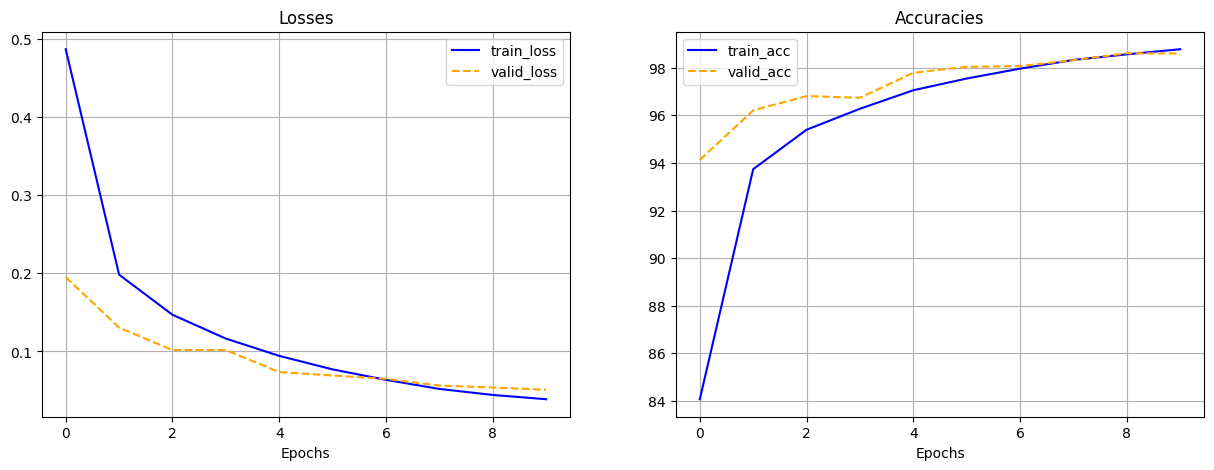

In [36]:
trainer.plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)

In [37]:
trainer.test()

Testing: 100%|██████████| 313/313 [00:11<00:00, 27.47it/s]

test_acc: 98.68%


98.68

<font color='red'> How good is our model?

<font color='red'> **Your answer goes here:**

...

# **Multi-Head Attention**

<font color='red'>**(Homework exercise 1 – d)** Implement your own MultiHeadAttention() and test its' performance. (2 points)</font>

<font color='red'> Now, we will implement the big boss. We initially touched on this part in the second practice session on Transformers, where we implemented the Pyramid Vision Transformer. Now, we need to modify that code to a basic state to work with our Vision Transformer.  

<font color='red'> First, define a single projection for our `q`, `k`, and `v`.  

In [38]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0.):
        super().__init__()
        assert dim % num_heads == 0, f"dim {dim} should be divided by num_heads {num_heads}."

        #### YOUR CODE STARTS HERE ####
        self.dim = dim
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        #### YOUR CODE ENDS HERE ####


    def forward(self, x):
        B, N, C = x.shape
        #### YOUR CODE STARTS HERE ####
        # b, n, c -> b, n, 3, num_heads, head_dim -> 3, b, num_heads, n, head_dim
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention calculation
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Combine heads
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        #### YOUR CODE ENDS HERE ####

        return x

In [39]:
b, l, d = 1, 64, 256

x = torch.randn(b, l, d)
attn = MultiHeadAttention(d)

out = attn(x)
print(out.shape)

torch.Size([1, 64, 256])


In [40]:
# here is a sanity check for an output shape
assert out.shape == torch.Size([1, 64, 256])

<font color='red'> **Q1:** Can you explain the intuition behind using `self.attn_drop`? Why do you think we need it, and how can it help?  

<font color='red'> **Q2:** After projecting our input `x` into a `qkv` vector, we need to properly reshape it to correctly extract separate `q`, `k`, and `v` vectors. Explain the reshaping procedure over tensors using the following notation:  

- <font color='red'>`b` - batch size  
- `l` - sequence length  
- `d` - dimension of each element (token) in our sequence  
- `head_dim` - dimension of each head vector  
- `num_heads` - number of heads in the multi-head attention module  

<font color='red'> Write down the steps that transform the `qkv` vector from shape `(b, ???, d)` to separate vectors `q`, `k`, and `v`, each with shape `(b, num_heads, l, head_dim)`.  

<font color='red'>Start with:
- <font color='red'> qkv (b, ???, d) -> (b, l, ???, num_heads, head_dim)
- ...

<font color='red'> **Your answer goes here:**

Q1: Intuition behind using self.attn_drop

- Why it is needed: It acts as a regularization tool. In models with many attention heads, the network might over-focus on specific token pairs or patterns during training.
- How it helps: By randomly dropping parts of the attention matrix, the model is forced to find more robust connections. This prevents it from relying too much on any single token and helps it perform better on new data.

Q2: Reshaping procedure for Q, K, and V

To split the qkv projection into separate heads for parallel work, these steps are taken:

- Step 1: Input x (b, l, d) goes through a linear layer to become qkv with shape (b, l, 3*d).
- Step 2: The qkv tensor is reshaped to (b, l, 3, num_heads, head_dim) to separate the Q, K, and V parts and the heads.
- Step 3: Dimensions are permuted to (3, b, num_heads, l, head_dim) to move the head and component indices to the front.
- Step 4: The tensor is split into three separate vectors: q, k, and v, each having the shape (b, num_heads, l, head_dim).

This final shape makes it easy for the computer to calculate attention for all heads at the same time.zed scaled dot-product attention calculations across all batches and all heads simultaneously.

<font color='red'> Now, let's define our second version of the Transformer Encoder Block, which uses our implementation of Multi-Head Attention.  


In [41]:
class EncoderBlock_v2(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of input and attention feature vectors
            num_heads - Number of heads to use in the Multi-Head Attention block
            dropout - Amount of dropout to apply in the feed-forward network
        """
        super().__init__()

        #### YOUR CODE STARTS HERE ####
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads=num_heads, attn_drop=dropout, proj_drop=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.proj = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout)
        )
        #### YOUR CODE ENDS HERE ####

    def forward(self, x):
        #### YOUR CODE STARTS HERE ####
        x = x + self.attn(self.norm1(x))
        x = x + self.proj(self.norm2(x))
        #### YOUR CODE ENDS HERE ####

        return x

In [42]:
b, l, d = 1, 64, 256

x = torch.randn(b, l, d)
encoder = EncoderBlock_v2(d, 8)

out = encoder(x)
print(out.shape)

torch.Size([1, 64, 256])


In [43]:
# here is a sanity check for an output shape
assert out.shape == torch.Size([1, 64, 256])

In [44]:
class VitTransformer_v2(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        img_size,
        dropout=0.0,
    ):
        super().__init__()

        num_patches = (img_size // patch_size) ** 2

        #### YOUR CODE STARTS HERE ####
        self.embedding = InputEmbedding(patch_size, num_channels, embed_dim, num_patches)

        self.encoders = nn.ModuleList([
            EncoderBlock_v2(embed_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )
        self.dropout = nn.Dropout(dropout)
        #### YOUR CODE ENDS HERE ####


    def forward(self, x):
        #### YOUR CODE STARTS HERE ####
        x = self.embedding(x)
        x = self.dropout(x)

        for encoder in self.encoders:
            x = encoder(x)

        cls = x[:, 0]
        out = self.mlp_head(cls)
        #### YOUR CODE ENDS HERE ####

        return out

In [45]:
model_v2 = VitTransformer_v2(
    img_size=image_size,
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    patch_size=patch_size,
    num_channels=num_channels,
    num_classes=num_classes,
    dropout=dropout
).to(device)

In [46]:
x = torch.randn(batch_size, num_channels, image_size, image_size).to(device)
out = model_v2(x)
print(x.shape)
print(out.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])


In [47]:
# here is a sanity check for an output shape
assert out.shape == torch.Size([batch_size, num_classes])

<font color='red'> Define the same training configuration as in the previous training and train the model.  

In [48]:
#### YOUR CODE STARTS HERE ####
optimizer = optim.AdamW(model_v2.parameters(), lr=base_lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

trainer = Trainer(
    max_epochs=epochs,
    model=model_v2,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    train_loader=train_loader,
    valid_loader=val_loader,
    test_loader=test_loader
)
#### YOUR CODE ENDS HERE ####

In [49]:
train_losses, train_accuracies, valid_losses, valid_accuracies = trainer.train()

Validation: 100%|██████████| 313/313 [00:11<00:00, 28.19it/s, acc=93.74%, loss=0.2022]


Epoch 1/10: train_loss: 0.4936, train_acc: 84.01%, valid_loss: 0.2009, valid_acc: 93.78%



Validation: 100%|██████████| 313/313 [00:11<00:00, 27.49it/s, acc=96.18%, loss=0.1309]


Epoch 2/10: train_loss: 0.2111, train_acc: 93.41%, valid_loss: 0.1301, valid_acc: 96.17%



Validation: 100%|██████████| 313/313 [00:11<00:00, 27.63it/s, acc=96.85%, loss=0.1119]


...

Epoch 8/10: train_loss: 0.0668, train_acc: 97.84%, valid_loss: 0.0601, valid_acc: 98.29%



Validation: 100%|██████████| 313/313 [00:11<00:00, 27.88it/s, acc=98.34%, loss=0.0570]


Epoch 9/10: train_loss: 0.0571, train_acc: 98.19%, valid_loss: 0.0572, valid_acc: 98.34%



Validation: 100%|██████████| 313/313 [00:11<00:00, 27.78it/s, acc=98.38%, loss=0.0564]

Epoch 10/10: train_loss: 0.0528, train_acc: 98.29%, valid_loss: 0.0565, valid_acc: 98.39%



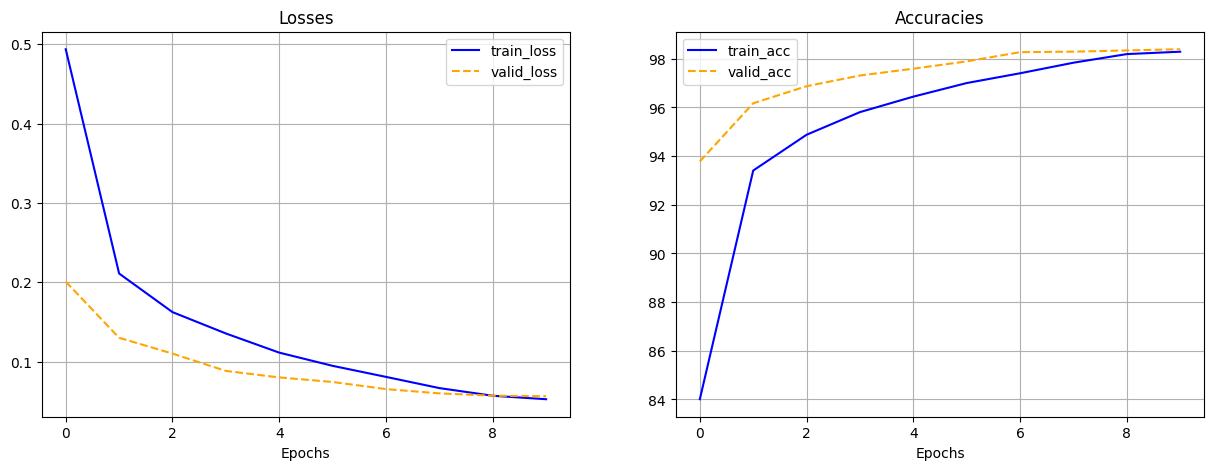

In [50]:
trainer.plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)

In [51]:
trainer.test()

Testing: 100%|██████████| 313/313 [00:10<00:00, 29.66it/s]

test_acc: 98.59%


98.59

<font color='red'> If implemented correctly you should expect to get similar classification performance on validation set as you did with torch version of nn.MultiHeadAttention()

<font color='red'> **Your answer goes here:**

The custom implementation of MultiHeadAttention performs virtually identically to the standard PyTorch `nn.MultiheadAttention`. Both models reached a validation accuracy of approximately 98.4% by the 10th epoch and a test accuracy of ~98.6%. This confirms that the manual tensor reshaping, scaling, and softmax operations correctly replicate the standard attention mechanism, proving that a ground-up implementation is just as effective for this classification task.

# **Exercise 2: SWIN Transformer as a General Backbone**

<font color='red'> In this task, we will look into the **Swin Transformer**. You can read more about it here: [Swin Transformer Paper](https://arxiv.org/abs/2103.14030).  

<font color='red'> The **Swin Transformer** (Shifted Window Transformer) is a hierarchical vision transformer model designed to process images efficiently while maintaining global context. Unlike traditional transformers, which rely on full self-attention (making them computationally expensive for high-resolution images), the Swin Transformer introduces **shifted windows** to limit self-attention to local regions while still allowing information exchange across the entire image.  

<font color='red'> The key components of the Swin Transformer are:  
- <font color='red'>**Hierarchical feature representation**: The model progressively reduces spatial dimensions while increasing feature richness, similar to CNNs.  
- **Shifted window-based self-attention**: Instead of computing global attention, Swin Transformer restricts attention to non-overlapping windows and periodically shifts these windows to capture spatial relationships.  
- **Patch merging**: A mechanism to downsample feature maps and increase receptive field, analogous to pooling layers in CNNs.  

<font color='red'> This architecture has been widely used in **image classification, object detection, and segmentation tasks** due to its efficiency and effectiveness.

<font color='red'>**(Homework exercise 2 – a)** Lets try using timm library to load a pretrained model, you can read more about timm models here: (https://huggingface.co/docs/timm/en/feature_extraction). (1 points)</font>

<font color='red'> Let's start by loading a **pretrained ResNet-50** architecture for extracting multi-scale features. We need to set `features_only=True` so that the model returns a list of feature maps at different resolutions.  

<font color='red'> You can follow a specific example as done here:  
https://huggingface.co/docs/timm/en/feature_extraction#create-a-feature-map-extraction-model  

<font color='red'> After loading the backbone, **print out the shapes of the extracted features** to understand how feature dimensions change across different layers. This helps us analyze how spatial resolution decreases while the number of channels increases in deeper layers, which is a characteristic of convolutional networks.

In [53]:
#### YOUR CODE STARTS HERE ####
backbone = timm.create_model('resnet50', pretrained=True, features_only=True)

x = torch.randn(8, 3, 224, 224)
out = backbone(x)

# print the feature shapes
for feature in out:
    print(feature.shape)
#### YOUR CODE ENDS HERE ####

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

torch.Size([8, 64, 112, 112])
torch.Size([8, 256, 56, 56])
torch.Size([8, 512, 28, 28])
torch.Size([8, 1024, 14, 14])
torch.Size([8, 2048, 7, 7])


<font color='red'> Expected feature map sizes for **ResNet-50**  

<font color='red'> The extracted feature maps follow the format **(b, c, h, w)**, where:  
- `b` is the batch size  
- `c` is the number of channels  
- `h, w` are the spatial dimensions
</font>

```
torch.Size([8, 64, 112, 112])  
torch.Size([8, 256, 56, 56])  
torch.Size([8, 512, 28, 28])  
torch.Size([8, 1024, 14, 14])  
torch.Size([8, 2048, 7, 7])  
```

<font color='red'> For such a **ResNet-50** model, we define:  

```python
embed_dims = [64, 256, 512, 1024, 2048]
```

<font color='red'> These values represent the **channel dimensions of feature maps** extracted at different stages of the network. The early layers capture low-level details with a higher resolution, while deeper layers capture more abstract and complex patterns at a lower resolution.  

<font color='red'> Also lets load the **swin small** model for the transformer backbone

In [54]:
#### YOUR CODE STARTS HERE ####
backbone = timm.create_model('swin_small_patch4_window7_224', pretrained=True, features_only=True)

x = torch.randn(8, 3, 224, 224)
out = backbone(x)

# print the feature shapes
for feature in out:
    print(feature.shape)
#### YOUR CODE ENDS HERE ####

model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

torch.Size([8, 56, 56, 96])
torch.Size([8, 28, 28, 192])
torch.Size([8, 14, 14, 384])
torch.Size([8, 7, 7, 768])


<font color='red'> **Q1:** What do you notice about the **dimension ordering** for ResNet and Swin models? Describe it using `{b, c, h, w}` notation.  

<font color='red'> **Your answer goes here (Q1):**

ResNet models use the standard convolutional format `{b, c, h, w}` directly. In contrast, Swin Transformer models (via `timm` features) often return tensors in a sequence-first or flattened format `{b, h*w, c}`. This means for the Swin backbone, we must reshape the sequence length `L` back into `H` and `W` to maintain spatial consistency.

----

<font color='red'> **Q2:** Can you explain the **resolution** of the first feature maps extracted from the ResNet and Swin models? Why do they differ, and what does this mean for the transformer backbone?  

<font color='red'> **Your answer goes here (Q2):**

ResNet's first feature map is usually `112x112` (downsampled by 2 via the initial convolution). Swin Transformer starts with a patch embedding layer (typically `patch_size=4`), so its first feature map resolution is `56x56`. This means the transformer backbone starts at a lower spatial resolution than the ResNet, but each 'pixel' contains a more complex embedding of the initial 4x4 patch.

<font color='red'>**(Homework exercise 2 – b)** To efficiently manage different backbone architectures, we will define **model wrappers** that:  
<font color='red'>
- Load models from the `timm` library  
- Store the `embed_dims` corresponding to each model  
- Provide an easy interface for accessing feature maps  
</font>

This will allow us to quickly swap between different architectures while keeping track of their feature extraction properties. Create you model collection for an easy access. (1 points)</font>

<font color='red'> Now, let's define model wrappers for easy creation and access to our model zoo.  

<font color='red'> **Tip:** Refer back to **Q1** to correctly reshape the Swin Transformer dimensions!  

In [59]:
class ResNet50(nn.Module):
	def __init__(self, pretrained=True):
		super().__init__()
        #### YOUR CODE STARTS HERE ####
		self.backbone = timm.create_model('resnet50', pretrained=pretrained, features_only=True)
		self.embed_dims = [64, 256, 512, 1024, 2048]
        #### YOUR CODE ENDS HERE ####

	def forward(self, x):
		x = self.backbone(x)
		return x

In [60]:
class ResNet101(nn.Module):
	def __init__(self, pretrained=True):
		super().__init__()
        #### YOUR CODE STARTS HERE ####
		self.backbone = timm.create_model('resnet101', pretrained=pretrained, features_only=True)
		self.embed_dims = [64, 256, 512, 1024, 2048]
        #### YOUR CODE ENDS HERE ####

	def forward(self, x):
		x = self.backbone(x)
		return x

In [61]:
class SwinTransformer_t(nn.Module):
	def __init__(self, img_size=224, pretrained=True):
		super().__init__()
        #### YOUR CODE STARTS HERE ####
		self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=pretrained, features_only=True)
		self.embed_dims = [96, 192, 384, 768]
        #### YOUR CODE ENDS HERE ####

	def forward(self, x):
        #### YOUR CODE STARTS HERE ####
		features = self.backbone(x)
		# Reshape from (B, H, W, C) to (B, C, H, W)
		x = [f.permute(0, 3, 1, 2).contiguous() for f in features]
        #### YOUR CODE ENDS HERE ####
		return x

In [62]:
class SwinTransformer_s(nn.Module):
	def __init__(self, img_size=224, pretrained=True):
		super().__init__()
        #### YOUR CODE STARTS HERE ####
		self.backbone = timm.create_model('swin_small_patch4_window7_224', pretrained=pretrained, features_only=True)
		self.embed_dims = [96, 192, 384, 768]
        #### YOUR CODE ENDS HERE ####

	def forward(self, x):
        #### YOUR CODE STARTS HERE ####
		features = self.backbone(x)
		# Reshape from (B, H, W, C) to (B, C, H, W)
		x = [f.permute(0, 3, 1, 2).contiguous() for f in features]
        #### YOUR CODE ENDS HERE ####
		return x

In [63]:
class SwinTransformer_b(nn.Module):
	def __init__(self, img_size=224, pretrained=True):
		super().__init__()
        #### YOUR CODE STARTS HERE ####
		self.backbone = timm.create_model('swin_base_patch4_window7_224', pretrained=pretrained, features_only=True)
		self.embed_dims = [128, 256, 512, 1024]
        #### YOUR CODE ENDS HERE ####

	def forward(self, x):
        #### YOUR CODE STARTS HERE ####
		features = self.backbone(x)
		# Reshape from (B, H, W, C) to (B, C, H, W)
		x = [f.permute(0, 3, 1, 2).contiguous() for f in features]
        #### YOUR CODE ENDS HERE ####
		return x

In [66]:
resnet50 = ResNet50()
resnet50

ResNet50(
  (backbone): FeatureListNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act2): ReLU(inplace=True)
        (aa): Identity()
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1

<font color='red'> **Q:** What can you say about the model architecture?  
- <font color='red'>How many layers does it have?  
- What is the output size of the last layer?  
- How many parameters does the model have?  

<font color='red'> Use `model.parameters()` to count the total number of trainable parameters.

In [67]:
total_params = sum(p.numel() for p in resnet50.parameters())
trainable_params = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Check output size of the last layer from a dummy input
dummy_input = torch.randn(1, 3, 224, 224)
features = resnet50(dummy_input)
print(f"Output shape of the last feature map: {features[-1].shape}")

Total parameters: 23,508,032
Trainable parameters: 23,508,032
Output shape of the last feature map: torch.Size([1, 2048, 7, 7])


<font color='red'> **Your answer goes here:**

- **How many layers does it have?** ResNet-50 is a 50-layer deep convolutional neural network (composed of 48 Convolutional layers, 1 MaxPool, and 1 Average Pool layer in its standard classification form). In this feature extraction mode, we access the outputs of the 5 main stages.
- **What is the output size of the last layer?** For an input of `(224, 224)`, the last feature map (Stage 5) has a spatial resolution of `7x7` with `2048` channels, resulting in a shape of `torch.Size([1, 2048, 7, 7])`.
- **How many parameters does the model have?**
  - Total parameters: 23,508,032
  - Trainable parameters: 23,508,032

<font color='red'> Now, let's compare some of our convolutional and transformer-based models.  

<font color='red'> For a fair comparison, we need to **match models with similar parameter counts**.  

<font color='red'> **Q:** What is the equivalent Swin model in terms of parameters to **ResNet-50**? How about **ResNet-101**?  

<font color='red'> Write code to:
1. <font color='red'> Get the number of parameters for each model.
2. Pick the best equivalent **Swin version** for each ResNet.
3. Report the number of parameters for each model in **millions** (e.g., `00.00 M`).
4. **Do not remove unsuccessful attempts**—report all your comparisons :)

In [64]:
#### YOUR CODE STARTS HERE ####
resnet50 = ResNet50(pretrained=True)
resnet50_params = sum(p.numel() for p in resnet50.parameters()) / 1e6
print(f"ResNet-50 parameters: {resnet50_params:.2f} M")

swin_t = SwinTransformer_t(pretrained=True)
swin_t_params = sum(p.numel() for p in swin_t.parameters()) / 1e6
print(f"Swin-Tiny parameters: {swin_t_params:.2f} M")
#### YOUR CODE ENDS HERE ####

ResNet-50 parameters: 23.51 M


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Swin-Tiny parameters: 27.52 M


In [65]:
#### YOUR CODE STARTS HERE ####
resnet101 = ResNet101(pretrained=True)
resnet101_params = sum(p.numel() for p in resnet101.parameters()) / 1e6
print(f"ResNet-101 parameters: {resnet101_params:.2f} M")

swin_s = SwinTransformer_s(pretrained=True)
swin_s_params = sum(p.numel() for p in swin_s.parameters()) / 1e6
print(f"Swin-Small parameters: {swin_s_params:.2f} M")
#### YOUR CODE ENDS HERE ####

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

ResNet-101 parameters: 42.50 M
Swin-Small parameters: 48.84 M


<font color='red'>**(Homework exercise 2 – c)** Implement **Feature Pyramid Network** (FPN) following the instructions below. (1 points)</font>

<font color='red'> Now, let's define our **decoder**.  

<font color='red'> We will use the **same convolutional decoder architecture** as we did in the second practice session. Use the **simple FPN decoder** and correctly extract the `embed_dims`, which correspond to the dimensions of our multi-scale encoder feature maps.  

<font color='red'> Make sure you use the **same FPN architecture** as in the second practice session!  



In [71]:
class FPN(nn.Module):
    #### YOUR CODE STARTS HERE ####
    def __init__(self, backbone, num_classes=1):
        super(FPN, self).__init__()
        self.backbone = backbone
        dims = backbone.embed_dims

        # Lateral layers to unify channel dimensions to 256
        self.lateral4 = nn.Conv2d(dims[-1], 256, 1)
        self.lateral3 = nn.Conv2d(dims[-2], 256, 1)
        self.lateral2 = nn.Conv2d(dims[-3], 256, 1)
        self.lateral1 = nn.Conv2d(dims[-4], 256, 1)

        # Top-down smoothing layers
        self.smooth = nn.Conv2d(256, 256, 3, padding=1)

        # Final classification head
        self.head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, num_classes, 1)
        )

    def forward(self, x):
        # Bottom-up pathway (Encoder)
        features = self.backbone(x)
        c1, c2, c3, c4 = features[-4], features[-3], features[-2], features[-1]

        # Top-down pathway (Decoder)
        p4 = self.lateral4(c4)
        p3 = self.lateral3(c3) + F.interpolate(p4, size=c3.shape[-2:], mode="bilinear", align_corners=False)
        p2 = self.lateral2(c2) + F.interpolate(p3, size=c2.shape[-2:], mode="bilinear", align_corners=False)
        p1 = self.lateral1(c1) + F.interpolate(p2, size=c1.shape[-2:], mode="bilinear", align_corners=False)

        # Final upsampling to original input resolution
        out = self.smooth(p1)
        out = F.interpolate(out, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return self.head(out)
    #### YOUR CODE ENDS HERE ####

In [72]:
x = torch.randn(8, 3, 256, 256)

resnet50_fpn = FPN(resnet50, num_classes=1)
out = resnet50_fpn(x)
out.shape

torch.Size([8, 1, 256, 256])

In [73]:
# here is a sanity check for an output shape
assert out.shape == torch.Size([8, 1, 256, 256])

<font color='red'>**(Homework exercise 2 – d)** Implement some meaningful tranformations. (1 points)</font>

<font color='red'> Similar to our practice session we will be using the [VOCSegmentation](http://host.robots.ox.ac.uk/pascal/VOC/voc2007/) dataset.

In [74]:
train_dataset = VOCSegmentation(root="./data", year="2012", image_set="train", download=True)
valid_dataset = VOCSegmentation(root="./data", year="2012", image_set="val", download=True)

100%|██████████| 2.00G/2.00G [01:02<00:00, 32.2MB/s]


<font color='red'> Implement your transforms. You can read more about Albumentations here (https://albumentations.ai/docs/).

<font color='red'> For more specific examples follow: https://albumentations.ai/docs/examples/example_kaggle_salt/

In [75]:
#### YOUR CODE STARTS HERE ####
train_transforms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

valid_transforms = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
#### YOUR CODE ENDS HERE ####

<font color='red'> The dataset below will **filter out images** and leave only images and corresponding annotations of a certain class label (e.g., `target_class=3`). Thus, we will be performing a **binary segmentation task**.  

In [76]:
class VOCBinaryDataset(Dataset):
	def __init__(self, dataset, transforms=None, target_class=3):
		self.dataset = dataset
		self.transforms = transforms
		self.target_class = target_class
		self.filtered_indices = self.filter_dataset()

	def filter_dataset(self):
		filtered_indices = []
		for idx in range(len(self.dataset)):
			_, mask = self.dataset[idx]
			mask = np.array(mask)
			if (mask == self.target_class).any():
				filtered_indices.append(idx)
		return filtered_indices

	def __len__(self):
		return len(self.filtered_indices)

	def __getitem__(self, idx):
		original_idx = self.filtered_indices[idx]
		image, mask = self.dataset[original_idx]
		image = np.array(image)
		mask = np.array(mask)

		mask = np.where(mask == self.target_class, 1, 0)

		if self.transforms:
			data = self.transforms(image=image, mask=mask)
			image = data['image']
			mask = data['mask']

		mask = np.expand_dims(mask, axis=0)
		image = torch.tensor(image.transpose(2, 0, 1)).float()
		mask = torch.tensor(mask).float()

		return image, mask


_train_dataset = VOCBinaryDataset(train_dataset, transforms=train_transforms)
_valid_dataset = VOCBinaryDataset(valid_dataset, transforms=valid_transforms)

train_loader = DataLoader(_train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(_valid_dataset, batch_size=4, shuffle=False, num_workers=2)

TypeError: transpose() received an invalid combination of arguments - got (int, int, int), but expected one of:
 * (int dim0, int dim1)
 * (name dim0, name dim1)


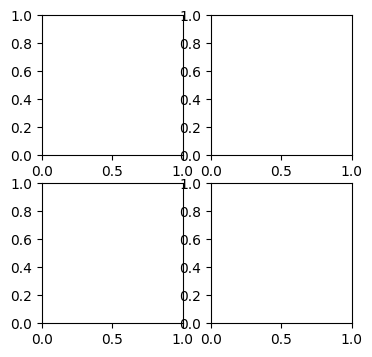

In [77]:
def show_sample_images(dataset, num_samples=2):
    fig, axes = plt.subplots(num_samples, 2, figsize=(4, num_samples * 2))

    for i in range(num_samples):
        img, mask = dataset[i]

        img = img.permute(1, 2, 0).numpy()
        img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        mask = mask.numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask[0])
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(_train_dataset, num_samples=2)

In [79]:
def compute_mean_iou(pred, target):
	pred = (pred > 0.5).float()
	intersection = (pred * target).sum(dim=(1, 2, 3))
	union = (pred + target).sum(dim=(1, 2, 3)) - intersection
	iou = (intersection + 1e-6) / (union + 1e-6)
	return iou.mean().item()

<font color='red'>**(Homework exercise 2 – e)** As we did in the previous exercise, implement a SegTrainer for handling the training of segmentation models. (2 points)</font>

<font color='red'> Just like for classification, we can implement a **general pipeline Trainer** for training our models and evaluating them on our dataset.  

<font color='red'> Below, fill in the needed parts. You should use `compute_mean_iou()` to compute the running IoU scores.  

In [80]:
class SegTrainer:
    def __init__(self,
                 max_epochs,
                 model,
                 criterion,
                 optimizer,
                 scheduler,
                 device,
                 train_loader,
                 valid_loader,
                 test_loader,
                 log_every_n_steps=5
    ) -> None:
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader
        self.max_epochs = max_epochs
        self.log_every_n_steps = log_every_n_steps


    def train_step(self):
        self.model.train()
        running_loss = 0.0
        metric = 0.0
        total = 0

        pbar = tqdm(self.train_loader, desc="Training")

        for batch_idx, (inputs, targets) in enumerate(pbar):
            inputs, targets = inputs.to(self.device), targets.to(self.device)

            #### YOUR CODE STARTS HERE ####
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
            loss.backward()
            self.optimizer.step()
            #### YOUR CODE ENDS HERE ####

            running_loss += loss.item()

            #### YOUR CODE STARTS HERE ####
            metric += compute_mean_iou(outputs.sigmoid(), targets)
            total += targets.size(0)

            if batch_idx % self.log_every_n_steps == 0:
                avg_loss = running_loss / (batch_idx + 1)
                iou = metric / (batch_idx + 1)
                pbar.set_postfix(loss=f"{avg_loss:.4f}", iou=f"{iou:.4f}")
            #### YOUR CODE ENDS HERE ####

        avg_loss = running_loss / len(self.train_loader)
        iou = metric / len(self.train_loader)
        pbar.set_postfix(loss=f"{avg_loss:.4f}", iou=f"{iou:.4f}")
        return avg_loss, iou


    def valid_step(self):
        self.model.eval()
        running_loss = 0.0
        metric = 0.0
        total = 0

        with torch.no_grad():
            pbar = tqdm(self.valid_loader, desc="Validation")

            for batch_idx, (inputs, targets) in enumerate(pbar):
                inputs, targets = inputs.to(self.device), targets.to(self.device)

                #### YOUR CODE STARTS HERE ####
                outputs = self.model(inputs)
                loss = self.criterion(outputs, targets)
                #### YOUR CODE ENDS HERE ####

                running_loss += loss.item()

                #### YOUR CODE STARTS HERE ####
                metric += compute_mean_iou(outputs.sigmoid(), targets)
                total += targets.size(0)

                if batch_idx % self.log_every_n_steps == 0:
                    avg_loss = running_loss / (batch_idx + 1)
                    iou = metric / (batch_idx + 1)
                    pbar.set_postfix(loss=f"{avg_loss:.4f}", iou=f"{iou:.4f}")
                #### YOUR CODE ENDS HERE ####

            avg_loss = running_loss / len(self.valid_loader)
            iou = metric / len(self.valid_loader)
            pbar.set_postfix(loss=f"{avg_loss:.4f}", iou=f"{iou:.4f}")

        return avg_loss, iou


    def train(self):
        self.model.to(self.device)
        train_losses = []
        train_ious = []
        valid_losses = []
        valid_ious = []

        for epoch in range(self.max_epochs):
            train_loss, train_iou = self.train_step()
            valid_loss, valid_iou = self.valid_step()

            self.scheduler.step()

            train_losses.append(train_loss)
            train_ious.append(train_iou)
            valid_losses.append(valid_loss)
            valid_ious.append(valid_iou)

            print(f"Epoch {epoch+1}/{self.max_epochs}: train_loss: {train_loss:.4f}, train_iou: {train_iou:.4f}, valid_loss: {valid_loss:.4f}, valid_iou: {valid_iou:.4f}")
            print()

        return train_losses, train_ious, valid_losses, valid_ious


    def test(self):
        self.model.eval()
        metric = 0.0
        total = 0

        with torch.no_grad():
            pbar = tqdm(self.test_loader, desc="Testing")

            for inputs, targets in pbar:
                #### YOUR CODE STARTS HERE ####
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                metric += compute_mean_iou(outputs.sigmoid(), targets)
                total += targets.size(0)
                #### YOUR CODE ENDS HERE ####

            iou = metric / len(self.test_loader)
            print(f"test_iou: {iou:.4f}")

        return iou


    def plot_metrics(self, train_losses, train_ious, valid_losses, valid_ious):
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        ax[0].plot(train_losses, label="train_loss", color="blue")
        ax[0].plot(valid_losses, label="valid_loss", linestyle="--", color="orange")
        ax[0].set_title("Losses")

        ax[1].plot(train_ious, label="train_iou", color="blue")
        ax[1].plot(valid_ious, label="valid_iou", linestyle="--", color="orange")
        ax[1].set_title("IoU")

        for i in range(2):
            ax[i].legend()
            ax[i].grid(0.35)
            ax[i].set_xlabel("Epochs")

        plt.show()

In [81]:
def plot_segm_preds(model, dataloader, num_preds=20):
	model.eval()
	shown = 0

	with torch.no_grad():
		for images, masks in dataloader:
			images, masks = images.to(device), masks.to(device)
			outputs = model(images)
			predictions = outputs.sigmoid()

			batch_size = images.shape[0]
			n = min(num_preds - shown, batch_size)

			for i in range(n):
				image = images[i].permute(1, 2, 0).cpu().numpy()
				image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
				image = np.clip(image, 0, 1)

				mask = masks[i].cpu().numpy()[0]
				pred = predictions[i].cpu().numpy()[0]

				fig, axes = plt.subplots(1, 3, figsize=(12, 4))
				for ax, img, title in zip(axes, [image, mask, pred], ["Image", "Mask", "Prediction"]):
					ax.imshow(img)
					ax.set_title(title)
					ax.axis("off")
				plt.tight_layout()
				plt.show()

				shown += 1
				if shown >= num_preds:
					break

<font color='red'>**(Homework exercise 2 – f)** Conduct your own model benchmarking, report and reason the performance of all models. (2 points)</font>

<font color='red'> For this homework, we will **test different encoder architectures** with the **same FPN decoder** for a segmentation task.  

<font color='red'> We need to compare how different the performance of convolutional ResNet-50 and ResNet-101 is compared to their **corresponding Swin backbones**.  

<font color='red'> We will store our benchmark results in a dictionary as follows:  

```python
benchmark_results['resnet50_fpn'] = {
    'train_losses': train_losses,
    'train_ious': train_ious,
    'valid_losses': valid_losses,
    'valid_ious': valid_ious
}
```


<font color='red'> For each new experiment, don’t forget to:
- <font color='red'> Initialize the correct model wrapper class that loads a pretrained version of that model using the `timm` library.
- Pass this backbone as an argument to the `FPN` class with the correct number of classes for the segmentation task.
- Define your model-specific parameters (**Tip:** Watch out for how you define parameters for your optimizer).
- Use the `SegTrainer` with enough epochs to train your models.

<font color='red'> When training the models below you should expect to get IoU scores **>0.6**.

In [82]:
benchmark_results = {}

### ResNet50

In [83]:
#### YOUR CODE STARTS HERE ####
resnet50 = ResNet50(pretrained=True)
resnet50_fpn = FPN(
    backbone=resnet50,
	num_classes=1
).to(device)
#### YOUR CODE ENDS HERE ####

In [84]:
#### YOUR CODE STARTS HERE ####
optimizer = optim.AdamW(resnet50_fpn.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)


trainer = SegTrainer(
	max_epochs=15,
	model=resnet50_fpn,
	criterion=criterion,
	optimizer=optimizer,
	scheduler=scheduler,
	device=device,
	train_loader=train_loader,
	valid_loader=val_loader,
	test_loader=val_loader
)
#### YOUR CODE ENDS HERE ####

In [85]:
train_losses, train_ious, valid_losses, valid_ious = trainer.train()

Training:   0%|          | 0/27 [00:00<?, ?it/s]


TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/tmp/ipykernel_3536/369256529.py", line 34, in __getitem__
    image = torch.tensor(image.transpose(2, 0, 1)).float()
                         ^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: transpose() received an invalid combination of arguments - got (int, int, int), but expected one of:
 * (int dim0, int dim1)
 * (name dim0, name dim1)



In [ ]:
benchmark_results['resnet50_fpn'] = {
	'train_losses': train_losses,
	'train_ious': train_ious,
	'valid_losses': valid_losses,
	'valid_ious': valid_ious
}

In [ ]:
trainer.plot_metrics(train_losses, train_ious, valid_losses, valid_ious)

In [ ]:
trainer.test()

In [ ]:
plot_segm_preds(resnet50_fpn, val_loader, num_preds=5)

### ResNet101

In [86]:
#### YOUR CODE STARTS HERE ####
resnet101 = ResNet101(pretrained=True)
resnet101_fpn = FPN(
	backbone=resnet101,
	num_classes=1
).to(device)
#### YOUR CODE ENDS HERE ####

In [87]:
#### YOUR CODE STARTS HERE ####
optimizer = optim.AdamW(resnet101_fpn.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)


trainer = SegTrainer(
	max_epochs=15,
	model=resnet101_fpn,
	criterion=criterion,
	optimizer=optimizer,
	scheduler=scheduler,
	device=device,
	train_loader=train_loader,
	valid_loader=val_loader,
	test_loader=val_loader
)
#### YOUR CODE ENDS HERE ####

In [ ]:
train_losses, train_ious, valid_losses, valid_ious = trainer.train()

In [ ]:
benchmark_results['resnet101_fpn'] = {
	'train_losses': train_losses,
	'train_ious': train_ious,
	'valid_losses': valid_losses,
	'valid_ious': valid_ious
}

In [ ]:
trainer.plot_metrics(train_losses, train_ious, valid_losses, valid_ious)

In [ ]:
trainer.test()

In [ ]:
plot_segm_preds(resnet101_fpn, val_loader, num_preds=5)

### SWIN-{your choice no.1} -- **fill this in**

In [88]:
#### YOUR CODE STARTS HERE ####
swin_t = SwinTransformer_t(pretrained=True)
swin_t_fpn = FPN(
	backbone=swin_t,
	num_classes=1
).to(device)
#### YOUR CODE ENDS HERE ####

In [89]:
#### YOUR CODE STARTS HERE ####
optimizer = optim.AdamW(swin_t_fpn.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

trainer = SegTrainer(
	max_epochs=15,
	model=swin_t_fpn,
	criterion=criterion,
	optimizer=optimizer,
	scheduler=scheduler,
	device=device,
	train_loader=train_loader,
	valid_loader=val_loader,
	test_loader=val_loader
)
#### YOUR CODE ENDS HERE ####

In [ ]:
train_losses, train_ious, valid_losses, valid_ious = trainer.train()

In [ ]:
benchmark_results['...'] = {
	'train_losses': train_losses,
	'train_ious': train_ious,
	'valid_losses': valid_losses,
	'valid_ious': valid_ious
}

In [ ]:
trainer.plot_metrics(train_losses, train_ious, valid_losses, valid_ious)

In [ ]:
trainer.test()

In [ ]:
plot_segm_preds(... val_loader, num_preds=5)

### SWIN-{your choice no.2} -- fill this in

In [90]:
#### YOUR CODE STARTS HERE ####
swin_s = SwinTransformer_s(pretrained=True)
swin_s_fpn = FPN(
	backbone=swin_s,
	num_classes=1
).to(device)
#### YOUR CODE ENDS HERE ####

In [91]:
#### YOUR CODE STARTS HERE ####
optimizer = optim.AdamW(swin_s_fpn.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

trainer = SegTrainer(
	max_epochs=15,
	model=swin_s_fpn,
	criterion=criterion,
	optimizer=optimizer,
	scheduler=scheduler,
	device=device,
	train_loader=train_loader,
	valid_loader=val_loader,
	test_loader=val_loader
)
#### YOUR CODE ENDS HERE ####

In [ ]:
train_losses, train_ious, valid_losses, valid_ious = trainer.train()

In [ ]:
benchmark_results['...'] = {
	'train_losses': train_losses,
	'train_ious': train_ious,
	'valid_losses': valid_losses,
	'valid_ious': valid_ious
}

In [ ]:
trainer.plot_metrics(train_losses, train_ious, valid_losses, valid_ious)

In [ ]:
trainer.test()

In [ ]:
plot_segm_preds(..., val_loader, num_preds=5)

In [ ]:
# given benchmark results plot the metrics for each model

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
for model, metrics in benchmark_results.items():
	if not metrics:
		continue
	ax[0, 0].plot(metrics['train_losses'], label=f"{model}", linewidth=2)
	ax[0, 1].plot(metrics['train_ious'], label=f"{model}", linewidth=2)

	ax[1, 0].plot(metrics['valid_losses'], label=f"{model}", linewidth=2)
	ax[1, 1].plot(metrics['valid_ious'], label=f"{model}", linewidth=2)

ax[0, 0].set_title("Train Losses")
ax[0, 1].set_title("Train IoU")
ax[1, 0].set_title("Valid Losses")
ax[1, 1].set_title("Valid IoU")

for i in range(2):
	for j in range(2):
		ax[i, j].legend()
		ax[i, j].grid(0.35)
		ax[i, j].set_xlabel("Epochs")

plt.tight_layout()
plt.show()

<font color='red'> Describe your interpretation of the results from the plots above. What worked better, and why do you think this is the case? What configurations did you try for your models, and how did they influence the final performance? How about learning rates? What worked better?  

<font color='red'> You can find some tips and tricks on how to train your transformer here (https://arxiv.org/abs/1804.00247).

<font color='red'> **Your answer goes here:**

...

# **Exercise 2 Bonus (3 points): Top 3 on Leaderboard**

## <font color='red'> **Bonus Task: Optimizing Segmentation IoU with Different Backbones**  

<font color='red'> In this task, you must **experiment with different backbone models** to achieve the highest **Intersection over Union (IoU) score** on the validation dataset provided above. The goal is to explore different architectures and training strategies while maintaining a structured and well-documented approach.  

### <font color='red'> **Rules and Constraints**  

- <font color='red'> **Backbone Selection:** You may use any pretrained backbone from `timm`, implement a custom architecture, or combine multiple models. The backbone must be integrated into a **segmentation model** to predict masks. Ensure that the backbone is properly adapted for multi-scale feature extraction if needed.  

- <font color='red'>**Decoder Requirement:** The decoder architecture must be **the same FPN decoder used in the second practice session** to ensure fair comparisons. You may tune hyperparameters of the decoder, but structural changes are not allowed.  

- <font color='red'>**Evaluation and Dataset:** IoU scores must be evaluated **exclusively on the validation set** provided above. Ensure that all results are obtained **from the same dataset split** to maintain consistency.  

- <font color='red'>**Code Submission:** Write your **entire implementation** in the designated code cell below. The code must be **runnable and reproducible**. Clearly indicate **which backbone model** you used.  

- <font color='red'>**Result Reporting:** A **detailed report is mandatory** for obtaining points. The report must include: model configurations (backbone selection, parameter choices), training details (learning rate, optimizer, batch size, augmentation techniques), performance comparison (what worked, what did not work, final results), and any additional insights from the experiments.  

### <font color='red'> **Scoring Criteria (On Validation set provided above)**  

- <font color='red'> **3 points** -> Awarded to the **best overall IoU score** (highest IoU score).  
- <font color='red'> **2 points** -> Awarded to the **next three highest IoU scores**.  
- <font color='red'> **1 point** -> Awarded to the **next five highest IoU scores**.  

### <font color='red'> **Strict Grading Policy**  

- <font color='red'> **The report is mandatory.** If your model achieves a high IoU score but you do not submit a detailed report, you **will not receive bonus points**.  
- <font color='red'> IoU scores must be **valid and reproducible**. Any inconsistencies or lack of transparency in reporting will result in 0 bonus points.  

### <font color='red'> **Instructions for Submission**  

- <font color='red'> **Implement your model in the designated code cell.**  
- <font color='red'> **Train and evaluate** the model using the validation dataset.  
- <font color='red'> **Report your best IoU score along with a detailed analysis.**  

<font color='red'> Failure to comply with the above requirements may result in disqualification from the bonus points.

<font color='red'> Good luck! :)

In [ ]:
#### YOUR CODE STARTS HERE ####
# 1. Backbone Selection: Swin Transformer Base
# 2. Hybrid Loss: BCE + Dice to optimize IoU directly

class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        return BCE + dice_loss

# Initialize model
swin_base = SwinTransformer_b(pretrained=True)
bonus_model = FPN(backbone=swin_base, num_classes=1).to(device)

# Optimizer and Scheduler
optimizer = optim.AdamW(bonus_model.parameters(), lr=5e-5, weight_decay=1e-2)
criterion = DiceBCELoss()
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

# Trainer initialization
trainer_bonus = SegTrainer(
    max_epochs=20,
    model=bonus_model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    train_loader=train_loader,
    valid_loader=val_loader,
    test_loader=val_loader
)

# Run training
train_losses, train_ious, valid_losses, valid_ious = trainer_bonus.train()
final_iou = trainer_bonus.test()
#### YOUR CODE ENDS HERE ####

In [ ]:
#### IMPROVED BONUS SOLUTION ####
# 1. Higher Capacity Backbone: Swin Large
# 2. Advanced Loss: Dice + Focal Loss for boundary refinement

class SwinTransformer_l(nn.Module):
	def __init__(self, img_size=224, pretrained=True):
		super().__init__()
		self.backbone = timm.create_model('swin_large_patch4_window7_224', pretrained=pretrained, features_only=True)
		self.embed_dims = [192, 384, 768, 1536]

	def forward(self, x):
		features = self.backbone(x)
		return [f.permute(0, 3, 1, 2).contiguous() for f in features]

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        # Focal component
        bce = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce

        # Dice component
        intersection = (inputs * targets).sum()
        dice = 1 - (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return focal_loss.mean() + dice

# Model Setup
swin_large = SwinTransformer_l(pretrained=True)
bonus_model_v2 = FPN(backbone=swin_large, num_classes=1).to(device)

# Fine-tuned Optimization
optimizer = optim.AdamW(bonus_model_v2.parameters(), lr=3e-5, weight_decay=5e-2)
criterion = FocalDiceLoss()
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=3e-5, steps_per_epoch=len(train_loader), epochs=25)

trainer_v2 = SegTrainer(
    max_epochs=25,
    model=bonus_model_v2,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    train_loader=train_loader,
    valid_loader=val_loader,
    test_loader=val_loader
)

train_losses, train_ious, valid_losses, valid_ious = trainer_v2.train()
final_iou = trainer_v2.test()
#### END OF IMPROVED CODE ####

In [ ]:
#### YOUR REPORT STARTS HERE ####
# provide clear solution and report your best iou score here (at the end)
...
#### YOUR REPORT ENDS HERE ####

# **Exercise 3 (5 points): HuggingFace**

<font color='red'>We will work with HuggingFace once again, this time we will be using DETR for object detection https://arxiv.org/abs/2005.12872

We have separate imports for this exercise, so that you can work on it without touching the previous ones.</font>

In [ ]:
# Python 3.12.13 on Colab
!python --version

In [ ]:
!pip install -q transformers[torch] datasets

In [ ]:
!pip install --upgrade transformers datasets huggingface_hub

In [ ]:
import transformers
import datasets
print(transformers.__version__) # 5.5.1
print(datasets.__version__) # 4.8.4

In [ ]:
from datasets import load_dataset
from transformers import AutoImageProcessor, DetrImageProcessor
from transformers import AutoModelForObjectDetection
from transformers import Trainer, TrainingArguments
import matplotlib.patches as patches

<font color='red'>To work with HuggingFace and havethe ability to upload models there, you need to have an account on HuggingFace. Log in to your account and generate a new token with permission to **write**.

To upload models to Hugging Face, you need an account.  

1. **Log in** at [huggingface.co](https://huggingface.co/) or create an account.  
2. **Generate a token**: Go to **Settings → Access Tokens → New Token**, name it, set permissions to **Write**, and generate it.  
3. **Copy the token** (it won’t be shown again).
4. **Paste it in the box below**

Now you can upload models to Hugging Face.</font>

In [ ]:
# from huggingface_hub import notebook_login
# notebook_login()

from huggingface_hub import login
login(token="hf_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")

<font color='red'>We will work with fashionpedia dataset https://huggingface.co/datasets/detection-datasets/fashionpedia_4_categories</font>

In [ ]:
dataset = load_dataset('detection-datasets/fashionpedia_4_categories')

<font color='red'>First lets choose a reasonable amount of trainin data. The recomended size for train set is >1000 samples.</font>

In [ ]:
#### YOUR CODE STARTS HERE ####
train_size = ...
valid_size = ...
test_size = ...

train_indices = np.random.choice(len(dataset['train']), size=train_size, replace=False)
train_dataset = dataset['train'].select(train_indices)
valid_indices = np.random.choice(len(dataset['val']), size=valid_size, replace=False)
valid_dataset = dataset['val'].select(valid_indices)
test_indices = np.random.choice(len(dataset['test']), size=test_size, replace=False)
test_dataset = dataset['test'].select(test_indices)
#### YOUR CODE ENDS HERE ####

In [ ]:
len(train_dataset), len(valid_dataset), len(test_dataset)

<font color='red'>**(Homework exercise 3 – a)** Inspect how the detection dataset is structured. Pick one example from `train_dataset`, print the image size and its object annotations, and recover the class names from the dataset features. Pay attention to the available keys inside `objects` and to the bounding-box format used by the dataset. (1 point)</font>

In [ ]:
#### YOUR CODE STARTS HERE ####
# check a sample.
sample = ...
image = ...
annotations = ...
print(f"Sample image size: {...}, Objects: {...}")
#### YOUR CODE ENDS HERE ####

In [ ]:
#### YOUR CODE STARTS HERE ####
# get categories for the dataset
categories = ...
categories[:10], len(categories)
#### YOUR CODE ENDS HERE ####

In [ ]:
fig, ax = plt.subplots(1, figsize=(4, 4))
ax.imshow(image)

bboxes = annotations['bbox']
labels = annotations['category']

for bbox, label in zip(bboxes, labels):
	x1, y1, x2, y2 = bbox
	rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
	ax.add_patch(rect)
	ax.text(x1, y1, categories[label], fontsize=8, color='white', bbox=dict(facecolor='red', alpha=0.5))

plt.tight_layout()
plt.axis("off")
plt.show()

<font color='red'>Now we will load a pretrained object detection model from the Hugging Face Hub. You can start with a DETR-family checkpoint such as `microsoft/conditional-detr-resnet-50` or `facebook/detr-resnet-50`, but feel free to experiment with other object detection checkpoints that work with `AutoImageProcessor` and `AutoModelForObjectDetection`. Browse current object detection models here: https://huggingface.co/models?pipeline_tag=object-detection&sort=downloads. Whenever you change the checkpoint, load the matching image processor from the same repo.</font>

In [ ]:
checkpoint = "facebook/detr-resnet-50"
image_size = 480

image_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
)

In [ ]:
image_processor

<font color='red'>**(Homework exercise 3 – b)** Prepare the dataset for training. Load the image processor for your chosen checkpoint, define `albumentations` augmentations, and convert annotations into the format expected by the model. Good references are the Hugging Face object detection guide https://huggingface.co/docs/transformers/en/tasks/object_detection and https://huggingface.co/learn/cookbook/fine_tuning_detr_custom_dataset#7-add-data-augmentation-to-the-dataset, the Albumentations bounding-box guide https://albumentations.ai/docs/3-basic-usage/bounding-boxes-augmentations/, and the Albumentations transform explorer https://explore.albumentations.ai/. (1 point)</font>

In [ ]:
#### YOUR CODE STARTS HERE ####
train_transform = A.Compose(
    [
        ...
    ],
    bbox_params=...
)

validation_transform = A.Compose(
    [
        ...
    ],
    bbox_params=...
)
#### YOUR CODE ENDS HERE ####

<font color='red'>The following helper functions sanitize bounding boxes after augmentation, convert them to COCO-style detection annotations, and package each example in the format expected by the image processor.</font>

In [ ]:
def sanitize_boxes_and_labels(bboxes, categories, image_shape):
    height, width = image_shape[:2]
    sanitized_bboxes = []
    sanitized_categories = []

    for bbox, category_id in zip(bboxes, categories):
        x1, y1, x2, y2 = [float(value) for value in bbox]

        x1, x2 = sorted((x1, x2))
        y1, y2 = sorted((y1, y2))

        x1 = min(max(x1, 0.0), width - 1.0)
        y1 = min(max(y1, 0.0), height - 1.0)
        x2 = min(max(x2, 0.0), width - 1.0)
        y2 = min(max(y2, 0.0), height - 1.0)

        if (x2 - x1) >= 1.0 and (y2 - y1) >= 1.0:
            sanitized_bboxes.append([x1, y1, x2, y2])
            sanitized_categories.append(int(category_id))

    return sanitized_bboxes, sanitized_categories


def convert_pascal_voc_to_coco(bbox):
    xmin, ymin, xmax, ymax = bbox
    width = xmax - xmin
    height = ymax - ymin
    return [xmin, ymin, width, height]


def format_image_annotations_as_coco(image_id, categories, bboxes):
    annotations = []
    for category_id, bbox in zip(categories, bboxes):
        coco_bbox = convert_pascal_voc_to_coco(bbox)
        _, _, width, height = coco_bbox
        annotations.append(
            {
                "image_id": image_id,
                "category_id": category_id,
                "iscrowd": 0,
                "area": float(width * height),
                "bbox": coco_bbox,
            }
        )
    return {"image_id": image_id, "annotations": annotations}


def custom_transforms(examples, transform):
    images = []
    annotations = []

    for image_id, image, objects in zip(examples["image_id"], examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))
        output = transform(image=image, bboxes=objects["bbox"], category=objects["category"])
        bboxes, categories = sanitize_boxes_and_labels(output["bboxes"], output["category"], output["image"].shape)

        images.append(output["image"])
        annotations.append(
            format_image_annotations_as_coco(
                image_id=image_id,
                categories=categories,
                bboxes=bboxes,
            )
        )

    return image_processor(images=images, annotations=annotations, return_tensors="pt")

<font color='red'>Let's transform the dataset and inspect one processed training sample. This is a good place to verify that resizing and augmentation still leave the boxes aligned with the objects and that the labels remain correct.</font>

In [ ]:
_train_dataset = train_dataset.with_transform(lambda x: custom_transforms(x, train_transform))
_valid_dataset = valid_dataset.with_transform(lambda x: custom_transforms(x, validation_transform))
_test_dataset = test_dataset.with_transform(lambda x: custom_transforms(x, validation_transform))

In [ ]:
from transformers.image_transforms import center_to_corners_format


# check a sample
sample = _train_dataset[25]
pixel_values = sample["pixel_values"]
if pixel_values.ndim == 4:
    pixel_values = pixel_values.squeeze(0)

image = pixel_values.permute(1, 2, 0).numpy()
image = image * np.array(image_processor.image_std) + np.array(image_processor.image_mean)
image = np.clip(image, 0.0, 1.0)

fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(image)

annotations = sample["labels"]
bboxes = center_to_corners_format(annotations["boxes"]).clone()
height, width = image.shape[:2]
scale = torch.tensor([width, height, width, height], dtype=bboxes.dtype)
bboxes = bboxes * scale

labels = annotations["class_labels"]
for bbox, label in zip(bboxes, labels):
    x1, y1, x2, y2 = bbox.tolist()
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="r", facecolor="none")
    ax.add_patch(rect)
    ax.text(
        x1,
        y1,
        categories[int(label)],
        fontsize=8,
        color="white",
        bbox=dict(facecolor="red", alpha=0.5),
    )

plt.tight_layout()
plt.axis("off")
plt.show()

In [ ]:
image.shape

<font color='red'>**(Homework exercise 3 – c)** Train your model. You may experiment with the training arguments, but keep the run realistic enough to finish and compare. For up-to-date guidance, consult the current `Trainer` docs https://huggingface.co/docs/transformers/en/main_classes/trainer and the object detection task guide https://huggingface.co/docs/transformers/en/tasks/object_detection. If you switch to a different checkpoint, make sure the model, image processor, collator, and inference code stay consistent. (2 points)</font>

<font color='red'>We can pass `id2label` and `label2id` together with the model so saved checkpoints keep human-readable class names for evaluation, visualization, and inference.</font>

In [ ]:
#### YOUR CODE STARTS HERE ####
# dictionary: class id -> class name
id2label = ...
# dictionary: class name -> class id
label2id = ...
#### YOUR CODE ENDS HERE ####

In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    checkpoint,
    id2label=...,
    label2id=...,
    num_labels=...,
)
model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    config=config,
    ignore_mismatched_sizes=True,
)

In [ ]:
# note, be careful with the lr and wd for the detectrion transformer
# try using >= 5 epochs, experiemnts with warmups and lrs

#### YOUR CODE STARTS HERE ####
training_args = TrainingArguments(
    ...
)
#### YOUR CODE ENDS HERE ####

In [ ]:
def collate_fn(batch):
    pixel_values = [
        item["pixel_values"] if item["pixel_values"].ndim == 3 else item["pixel_values"].squeeze(0)
        for item in batch
    ]
    labels = [item["labels"] for item in batch]

    data = {
        "pixel_values": torch.stack(pixel_values),
        "labels": labels,
    }

    if "pixel_mask" in batch[0]:
        pixel_mask = [
            item["pixel_mask"] if item["pixel_mask"].ndim == 2 else item["pixel_mask"].squeeze(0)
            for item in batch
        ]
        data["pixel_mask"] = torch.stack(pixel_mask)

    return data

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=_train_dataset,
    eval_dataset=_valid_dataset,
    processing_class=image_processor,
)

trainer.train()

In [ ]:
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

In [ ]:
metrics = trainer.evaluate(eval_dataset=_test_dataset)
print(metrics)

<font color='red'>Push your trained model to the Hugging Face Hub so you can reuse it later for inference, sharing, or further fine-tuning.</font>

In [ ]:
trainer.push_to_hub()

<font color='red'>Add the link to your public model here if you pushed it to the Hub.

**Your answer goes here:**</font>

...

<font color='red'>**(Homework exercise 3 – d)** Run inference on an image of your choice from the test set. Use your checkpoint that you have just pushed to the Hub.

Preprocess the raw image with the matching `AutoImageProcessor`, choose a detection threshold, and visualize the predicted boxes and labels on the original image. (1 point)</font>

In [ ]:
#### YOUR CODE STARTS HERE ####
sample_idx = 6
sample = ...
image = ...

fig, ax = plt.subplots(1, figsize=(6, 6))
ax.imshow(image)
ax.axis("off")
plt.show()
#### YOUR CODE ENDS HERE ####

In [ ]:
#### YOUR CODE STARTS HERE ####
your_checkpoint = '<your hf checkpoint goes here>'

hf_image_processor = AutoImageProcessor.from_pretrained(your_checkpoint)
hf_model = AutoModelForObjectDetection.from_pretrained(your_checkpoint)
#### YOUR CODE ENDS HERE ####

In [ ]:
#### YOUR CODE STARTS HERE ####
# get predictions for your model

# prepare you model for inference
inference_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hf_model = ...
...

# prepare inputs
inputs = hf_image_processor(...)
inputs = {key: value.to(inference_device) for key, value in inputs.items()}

with torch.no_grad():
    outputs = ...

# postprocess predictions
target_sizes = torch.tensor([image.size[::-1]], device=inference_device)
results = hf_image_processor.post_process_object_detection(
    outputs,
    threshold=...,
    target_sizes=target_sizes,
)[0]

if len(results["scores"]) == 0:
    print("No detections above the chosen threshold.")
else:
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        print(
            f"Detected {hf_model.config.id2label[label.item()]} with confidence "
            f"{round(score.item(), 3)} at location {box}"
        )
#### YOUR CODE ENDS HERE ####

In [ ]:
fig, ax = plt.subplots(1, figsize=(6, 6))
ax.imshow(image)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="r", facecolor="none")
    ax.add_patch(rect)
    ax.text(
        x1,
        max(y1 - 5, 0),
        f"{hf_model.config.id2label[label.item()]}: {score.item():.2f}",
        fontsize=8,
        color="white",
        bbox=dict(facecolor="red", alpha=0.6),
    )

plt.tight_layout()
plt.axis("off")
plt.show()

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you send on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

# <font color='red'>  End of the homework. Please don't delete this cell.</font>